# Food Image Classification - Implementation of MLP Model

**Student**：Tianqi Gao

**Student ID**：2575703

**Model type**：Neural Network - Multi-Layer Perceptron (MLP)

**Data**: Image features extracted by pre-trained CNN (Mixed dataset: open-source data + self-collected data)

**Personal work**：Independently implement and evaluate the MLP classifier.

## Reasons for model selection

The reasons why I choose the Multi-layer perceptron (MLP)：

1. **Data characteristic adaptation**：Our feature dimension is 6190 dimensions, derived from a pre-trained CNN feature extractor. MLP is good at handling high-dimensional features and learning nonlinear relationships.

2. **Moderate complexity**：Compared with deep CNNS, MLP is simpler and faster to train, making it suitable as a basic model to evaluate the effectiveness of features.

3. **Extensibility**：MLP can increase the model capacity by adding more hidden layers and neurons, facilitating subsequent optimization.

4. **Comparative value**：It can serve as a benchmark for neural network models, in contrast to linear models (such as logistic regression) and ensemble methods (such as random forests).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional
import pandas as pd

## 1. Data Loading and preprocessing

This section loads the pre-extracted image features (from the pre-trained CNN) and performs standardization processing.

Standardize the use of the mean and variance of the training set to uniformly transform the train/val/test sets.

In [2]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", ".."))
DATA_DIR = os.path.join(PROJECT_ROOT, "Data")
FEATURE_DIR = os.path.join(DATA_DIR, "features")

TRAIN_FEATURES_PATH = os.path.join(FEATURE_DIR, "train_features.npy")
TRAIN_LABELS_PATH = os.path.join(FEATURE_DIR, "train_labels.npy")
VAL_FEATURES_PATH = os.path.join(FEATURE_DIR, "val_features.npy")
VAL_LABELS_PATH = os.path.join(FEATURE_DIR, "val_labels.npy")
TEST_FEATURES_PATH = os.path.join(FEATURE_DIR, "test_features.npy")
TEST_LABELS_PATH = os.path.join(FEATURE_DIR, "test_labels.npy")

CLASS_MAPPING_PATH = os.path.join(FEATURE_DIR, "class_mapping.npy")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FEATURE_DIR:", FEATURE_DIR)

X_train = np.load(TRAIN_FEATURES_PATH)
y_train = np.load(TRAIN_LABELS_PATH)
X_val = np.load(VAL_FEATURES_PATH)
y_val = np.load(VAL_LABELS_PATH)
X_test = np.load(TEST_FEATURES_PATH)
y_test = np.load(TEST_LABELS_PATH)

idx_to_class = np.load(CLASS_MAPPING_PATH, allow_pickle=True).item()
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
num_classes = len(class_names)
input_dim = X_train.shape[1]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Classes:", class_names)

# Standardize by train statistics
mean = X_train.mean(axis=0, keepdims=True)
std = X_train.std(axis=0, keepdims=True) + 1e-6

X_train_std = (X_train - mean) / std
X_val_std = (X_val - mean) / std
X_test_std = (X_test - mean) / std

print("Standardized feature shapes:")
print("  X_train_std:", X_train_std.shape)
print("  X_val_std:  ", X_val_std.shape)
print("  X_test_std: ", X_test_std.shape)

PROJECT_ROOT: C:\Users\Tianqi.Gao25\DTS402 Machine Learning\Tianqi.Gao_2575703_GroupWork\Food Classification
FEATURE_DIR: C:\Users\Tianqi.Gao25\DTS402 Machine Learning\Tianqi.Gao_2575703_GroupWork\Food Classification\Data\features
Train: (1800, 6190) (1800,)
Val:   (510, 6190) (510,)
Test:  (510, 6190) (510,)
Classes: ['bibimbap', 'chicken-curry', 'hamburger']
Standardized feature shapes:
  X_train_std: (1800, 6190)
  X_val_std:   (510, 6190)
  X_test_std:  (510, 6190)


## 2. Implementation of MLP Model

This section implements a multi-layer perceptron (MLP) using pure NumPy, including:
- Fully connected layer 'Dense'
Activate the function 'ReLU'
- 'Dropout' regularization
- 'SoftmaxWithLoss' loss and gradient
- Use the SGD optimizer of Momentum
The encapsulated 'MLPClassifier' class

In [3]:
class Dense:
    def __init__(self, in_features: int, out_features: int):
        limit = np.sqrt(6.0 / (in_features + out_features))
        self.W = np.random.uniform(-limit, limit, (in_features, out_features)).astype(np.float32)
        self.b = np.zeros((1, out_features), dtype=np.float32)

        self.x: Optional[np.ndarray] = None
        self.dW: Optional[np.ndarray] = None
        self.db: Optional[np.ndarray] = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.x = x
        return x @ self.W + self.b

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        assert self.x is not None
        batch_size = self.x.shape[0]
        self.dW = (self.x.T @ grad_output) / batch_size
        self.db = np.sum(grad_output, axis=0, keepdims=True) / batch_size
        grad_input = grad_output @ self.W.T
        return grad_input


class ReLU:
    def __init__(self):
        self.mask: Optional[np.ndarray] = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.mask = x > 0
        return x * self.mask

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        assert self.mask is not None
        return grad_output * self.mask


class Dropout:
    def __init__(self, p_drop: float):
        self.p_drop = p_drop
        self.mask: Optional[np.ndarray] = None

    def forward(self, x: np.ndarray, train: bool = True) -> np.ndarray:
        if not train or self.p_drop <= 0.0:
            return x
        keep_prob = 1.0 - self.p_drop
        self.mask = (np.random.rand(*x.shape) < keep_prob).astype(np.float32)
        return x * self.mask / keep_prob

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        if self.mask is None:
            return grad_output
        keep_prob = 1.0 - self.p_drop
        return grad_output * self.mask / keep_prob


class SoftmaxWithLoss:
    def __init__(self):
        self.probs: Optional[np.ndarray] = None
        self.y_true: Optional[np.ndarray] = None

    def forward(self, logits: np.ndarray, y_true: np.ndarray) -> float:
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

        self.probs = probs
        self.y_true = y_true

        eps = 1e-8
        log_likelihood = -np.log(np.sum(probs * y_true, axis=1) + eps)
        loss = np.mean(log_likelihood)
        return loss

    def backward(self) -> np.ndarray:
        assert self.probs is not None and self.y_true is not None
        grad_logits = (self.probs - self.y_true)
        return grad_logits

## 3. MLP classifier

In [4]:
class MLPClassifier:
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        hidden_layers: List[int],
        dropout_rate: float = 0.0,
        learning_rate: float = 1e-3,
        momentum: float = 0.9,
        lr_decay: float = 0.99,
    ):
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.hidden_layers = hidden_layers
        self.dropout_rate = dropout_rate
        self.lr = learning_rate
        self.momentum = momentum
        self.lr_decay = lr_decay

        self.layers: List = []
        prev_dim = input_dim
        for h_dim in hidden_layers:
            self.layers.append(Dense(prev_dim, h_dim))
            self.layers.append(ReLU())
            if dropout_rate > 0.0:
                self.layers.append(Dropout(dropout_rate))
            prev_dim = h_dim
        # output layer
        self.layers.append(Dense(prev_dim, num_classes))

        self.criterion = SoftmaxWithLoss()

        # momentum velocity
        self.velocities: Dict[int, Dict[str, np.ndarray]] = {}
        for idx, layer in enumerate(self.layers):
            if isinstance(layer, Dense):
                self.velocities[idx] = {
                    "W": np.zeros_like(layer.W),
                    "b": np.zeros_like(layer.b),
                }

    def _one_hot(self, y: np.ndarray) -> np.ndarray:
        y_oh = np.zeros((y.shape[0], self.num_classes), dtype=np.float32)
        y_oh[np.arange(y.shape[0]), y] = 1.0
        return y_oh

    def forward(self, X: np.ndarray, train: bool = True) -> np.ndarray:
        out = X
        for layer in self.layers:
            if isinstance(layer, Dropout):
                out = layer.forward(out, train=train)
            else:
                out = layer.forward(out)
        return out

    def compute_loss_and_gradients(self, X: np.ndarray, y: np.ndarray) -> Tuple[float, np.ndarray]:
        y_oh = self._one_hot(y)
        logits = self.forward(X, train=True)
        loss = self.criterion.forward(logits, y_oh)
        grad_logits = self.criterion.backward()
        return loss, grad_logits

    def backward(self, grad_logits: np.ndarray):
        grad = grad_logits
        for layer in reversed(self.layers):
            if isinstance(layer, (ReLU, Dense, Dropout)):
                grad = layer.backward(grad)

    def step(self):
        for idx, layer in enumerate(self.layers):
            if isinstance(layer, Dense):
                v = self.velocities[idx]
                v["W"] = self.momentum * v["W"] - self.lr * layer.dW
                v["b"] = self.momentum * v["b"] - self.lr * layer.db
                layer.W += v["W"]
                layer.b += v["b"]

    def predict(self, X: np.ndarray) -> np.ndarray:
        logits = self.forward(X, train=False)
        return np.argmax(logits, axis=1)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        logits = self.forward(X, train=False)
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        return probs

    def evaluate(self, X: np.ndarray, y: np.ndarray) -> Dict[str, np.ndarray]:
        logits = self.forward(X, train=False)
        preds = np.argmax(logits, axis=1)
        acc = (preds == y).mean()
        cm = confusion_matrix_np(y, preds, num_classes=self.num_classes)
        return {"accuracy": acc, "confusion_matrix": cm}

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
        num_epochs: int = 80,
        batch_size: int = 32,
        early_stopping: bool = True,
        patience: int = 15,
        verbose: bool = True,
    ) -> Dict[str, List[float]]:
        n_samples = X_train.shape[0]
        best_val_loss = np.inf
        best_state = None
        epochs_no_improve = 0

        history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": [],
            "lrs": [],
        }

        for epoch in range(1, num_epochs + 1):
            # shuffle
            idx = np.random.permutation(n_samples)
            X_train_shuf = X_train[idx]
            y_train_shuf = y_train[idx]

            epoch_loss = 0.0
            correct = 0
            total = 0

            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_train_shuf[start:end]
                y_batch = y_train_shuf[start:end]

                loss, grad_logits = self.compute_loss_and_gradients(X_batch, y_batch)
                self.backward(grad_logits)
                self.step()

                epoch_loss += loss * X_batch.shape[0]

                logits_batch = self.forward(X_batch, train=False)
                preds = np.argmax(logits_batch, axis=1)

                correct += np.sum(preds == y_batch)
                total += X_batch.shape[0]

            train_loss = epoch_loss / total
            train_acc = correct / total

            # validation
            logits_val = self.forward(X_val, train=False)
            y_val_oh = self._one_hot(y_val)
            val_loss = self.criterion.forward(logits_val, y_val_oh)
            val_preds = np.argmax(self.criterion.probs, axis=1)
            val_acc = (val_preds == y_val).mean()

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)
            history["lrs"].append(self.lr)

            if verbose:
                print(
                    f"Epoch [{epoch}/{num_epochs}] lr={self.lr:.5f} "
                    f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
                    f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
                )

            # early stopping
            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                best_state = [(layer.W.copy(), layer.b.copy())
                              for layer in self.layers if isinstance(layer, Dense)]
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if early_stopping and epochs_no_improve >= patience:
                    if verbose:
                        print(
                            f"[Early Stopping] best val_loss={best_val_loss:.4f} "
                            f"at epoch {epoch - patience}"
                        )
                    break

            # lr decay
            self.lr *= self.lr_decay

        # Restore best parameters
        if best_state is not None:
            dense_layers = [layer for layer in self.layers if isinstance(layer, Dense)]
            for (W_best, b_best), layer in zip(best_state, dense_layers):
                layer.W = W_best
                layer.b = b_best

        return history

## 4. Evaluation Tools and Hyperparameter Search

To evaluate the performance of the MLP model, this section first implements several NumPy versions of the evaluation functions:
- Confusion matrix, accuracy, macro average Precision/Recall/F1
- ROC curve and AUC
- The Precision-Recall curve and AP

Subsequently, a simple random search hyperparameter experiment was conducted to observe the influence of different hyperparameter Settings on the performance of the validation set and the degree of overfitting.

In [5]:
def confusion_matrix_np(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    """
    rows: true labels, cols: predicted labels
    """
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def accuracy_np(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return (y_true == y_pred).mean()


def precision_recall_f1_macro(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int):
    cm = confusion_matrix_np(y_true, y_pred, num_classes)
    eps = 1e-8

    precisions = []
    recalls = []
    f1s = []

    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    precision_macro = float(np.mean(precisions))
    recall_macro = float(np.mean(recalls))
    f1_macro = float(np.mean(f1s))
    return precision_macro, recall_macro, f1_macro


def roc_curve_np(y_true: np.ndarray, y_score: np.ndarray):
    """
    Binary ROC curve (NumPy)
    y_true: (N,), 0/1
    y_score: (N,), score for class 1
    """
    desc_score_indices = np.argsort(-y_score)
    y_score_sorted = y_score[desc_score_indices]
    y_true_sorted = y_true[desc_score_indices]

    distinct_value_indices = np.where(np.diff(y_score_sorted))[0]
    threshold_idxs = np.r_[distinct_value_indices, y_true_sorted.size - 1]

    tps = np.cumsum(y_true_sorted)[threshold_idxs]
    fps = 1 + threshold_idxs - tps

    P = y_true.sum()
    N = y_true.size - P

    tpr = tps / (P + 1e-12)
    fpr = fps / (N + 1e-12)

    thresholds = y_score_sorted[threshold_idxs]
    return fpr, tpr, thresholds


def auc_np(x: np.ndarray, y: np.ndarray) -> float:
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    return np.trapz(y_sorted, x_sorted)


def pr_curve_ovr(y_true: np.ndarray, y_proba: np.ndarray, num_classes: int, num_thresholds: int = 100):
    """
    Multi-class PR curve (OvR), NumPy only.
    """
    eps = 1e-8
    thresholds = np.linspace(0.0, 1.0, num=num_thresholds)

    prec_list = []
    rec_list = []
    ap_list = []

    for c in range(num_classes):
        y_true_bin = (y_true == c).astype(np.int32)
        scores = y_proba[:, c]

        precisions = []
        recalls = []

        for thr in thresholds:
            y_pred_bin = (scores >= thr).astype(np.int32)

            tp = np.sum((y_pred_bin == 1) & (y_true_bin == 1))
            fp = np.sum((y_pred_bin == 1) & (y_true_bin == 0))
            fn = np.sum((y_pred_bin == 0) & (y_true_bin == 1))

            precision = tp / (tp + fp + eps)
            recall = tp / (tp + fn + eps)

            precisions.append(precision)
            recalls.append(recall)

        precisions = np.array(precisions)
        recalls = np.array(recalls)

        order = np.argsort(recalls)
        recalls = recalls[order]
        precisions = precisions[order]

        ap_val = float(np.trapz(precisions, recalls))

        prec_list.append(precisions)
        rec_list.append(recalls)
        ap_list.append(ap_val)

    return thresholds, prec_list, rec_list, ap_list


def roc_curve_ovr(y_true: np.ndarray, y_proba: np.ndarray, num_classes: int):
    """
    Multi-class ROC (OvR)，Return the fpr/tpr/AUC for each category
    """
    thresholds = None
    fpr_list = []
    tpr_list = []
    auc_list = []

    for c in range(num_classes):
        y_true_bin = (y_true == c).astype(np.int32)
        scores = y_proba[:, c]
        fpr, tpr, thr = roc_curve_np(y_true_bin, scores)
        auc_val = auc_np(fpr, tpr)

        if thresholds is None:
            thresholds = thr
        fpr_list.append(fpr)
        tpr_list.append(tpr)
        auc_list.append(auc_val)

    return thresholds, fpr_list, tpr_list, auc_list


def evaluate_classifier_np(
    name: str,
    clf_predict,
    clf_proba,
    X: np.ndarray,
    y: np.ndarray,
    num_classes: int,
):
    """
    Comprehensive evaluation of pure NumPy (including ROC/PR information)
    """
    y_pred = clf_predict(X)
    p_pred = clf_proba(X)

    acc = accuracy_np(y, y_pred)
    precision_macro, recall_macro, f1_macro = precision_recall_f1_macro(y, y_pred, num_classes)
    cm = confusion_matrix_np(y, y_pred, num_classes)

    thresholds, fpr_list, tpr_list, auc_list = roc_curve_ovr(y, p_pred, num_classes)
    thresholds_pr, prec_list, rec_list, ap_list = pr_curve_ovr(y, p_pred, num_classes)

    print(f"[{name}] accuracy={acc:.4f}, macro-F1={f1_macro:.4f}")
    print(f"[{name}] per-class ROC-AUC: {auc_list}")
    print(f"[{name}] per-class AP:      {ap_list}")
    print("Confusion matrix:\n", cm)

    return {
        "name": name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "confusion_matrix": cm,
        "roc_thresholds": thresholds,
        "fpr_list": fpr_list,
        "tpr_list": tpr_list,
        "roc_auc_list": auc_list,
        "pr_thresholds": thresholds_pr,
        "prec_list": prec_list,
        "rec_list": rec_list,
        "ap_list": ap_list,
        "y_true": y,
        "y_pred": y_pred,
        "p_pred": p_pred,
    }

In [34]:
def simple_hparam_search():
    configs = [
        {"hidden_layers": [256], "dropout": 0.5, "lr": 1e-3},
        {"hidden_layers": [128], "dropout": 0.5, "lr": 8e-4}, 
        {"hidden_layers": [64],  "dropout": 0.7, "lr": 5e-4},
        {"hidden_layers": [128], "dropout": 0.4, "lr": 8e-4},
        {"hidden_layers": [128], "dropout": 0.5, "lr": 7e-4},
        {"hidden_layers": [128], "dropout": 0.5, "lr": 6e-4},
        # Final selection
    ]
    results = []
    for cfg in configs:
        print("\nConfig:", cfg)
        mlp_tmp = MLPClassifier(
            input_dim=input_dim,
            num_classes=num_classes,
            hidden_layers=cfg["hidden_layers"],
            dropout_rate=cfg["dropout"],
            learning_rate=cfg["lr"],
            momentum=0.9,
            lr_decay=0.995,
        )
        history_tmp = mlp_tmp.fit(
            X_train_std, y_train,
            X_val_std, y_val,
            num_epochs=60,
            batch_size=32,
            early_stopping=True,
            patience=5,
            verbose=False,
        )
        best_val = max(history_tmp["val_acc"])
        best_train = max(history_tmp["train_acc"])
        print(f"  best train_acc={best_train:.4f}, best val_acc={best_val:.4f}")
        results.append({
            "hidden_layers": cfg["hidden_layers"],
            "dropout": cfg["dropout"],
            "lr": cfg["lr"],
            "best_train_acc": best_train,
            "best_val_acc": best_val,
        })
    return results

search_results = simple_hparam_search()
pd.DataFrame(search_results)


Config: {'hidden_layers': [256], 'dropout': 0.5, 'lr': 0.001}
  best train_acc=1.0000, best val_acc=0.7176

Config: {'hidden_layers': [128], 'dropout': 0.5, 'lr': 0.0008}
  best train_acc=0.9989, best val_acc=0.6941

Config: {'hidden_layers': [64], 'dropout': 0.7, 'lr': 0.0005}
  best train_acc=0.9744, best val_acc=0.6588

Config: {'hidden_layers': [128], 'dropout': 0.4, 'lr': 0.0008}
  best train_acc=1.0000, best val_acc=0.6882

Config: {'hidden_layers': [128], 'dropout': 0.5, 'lr': 0.0007}
  best train_acc=0.9989, best val_acc=0.6765

Config: {'hidden_layers': [128], 'dropout': 0.5, 'lr': 0.0006}
  best train_acc=0.9989, best val_acc=0.6941


,hidden_layers,dropout,lr,best_train_acc,best_val_acc
0,[256],0.5,0.0010,1.000000,0.717647
1,[128],0.5,0.0008,0.998889,0.694118
2,[64],0.7,0.0005,0.974444,0.658824
3,[128],0.4,0.0008,1.000000,0.688235
4,[128],0.5,0.0007,0.998889,0.676471
5,[128],0.5,0.0006,0.998889,0.694118


## 5. Final MLP model training and learning curve

This section retrains the MLP model using the selected hyperparameters and plots the training/validation loss and accuracy curves, as well as the changes in the learning rate, to observe the training process and the degree of overfitting.

Epoch [1/60] lr=0.00050 train_loss=1.9716, train_acc=0.5161, val_loss=1.0162, val_acc=0.5490
Epoch [2/60] lr=0.00050 train_loss=1.2863, train_acc=0.7061, val_loss=0.9899, val_acc=0.5902
Epoch [3/60] lr=0.00050 train_loss=1.0433, train_acc=0.7833, val_loss=0.8750, val_acc=0.6392
Epoch [4/60] lr=0.00049 train_loss=0.8822, train_acc=0.8339, val_loss=0.8698, val_acc=0.6451
Epoch [5/60] lr=0.00049 train_loss=0.7915, train_acc=0.8639, val_loss=0.8545, val_acc=0.6529
Epoch [6/60] lr=0.00049 train_loss=0.7024, train_acc=0.8867, val_loss=0.8667, val_acc=0.6529
Epoch [7/60] lr=0.00049 train_loss=0.6341, train_acc=0.9106, val_loss=0.8329, val_acc=0.6706
Epoch [8/60] lr=0.00048 train_loss=0.5757, train_acc=0.9256, val_loss=0.8311, val_acc=0.6804
Epoch [9/60] lr=0.00048 train_loss=0.5487, train_acc=0.9378, val_loss=0.8354, val_acc=0.6784
Epoch [10/60] lr=0.00048 train_loss=0.4751, train_acc=0.9483, val_loss=0.8412, val_acc=0.6647
Epoch [11/60] lr=0.00048 train_loss=0.4625, train_acc=0.9578, val_los

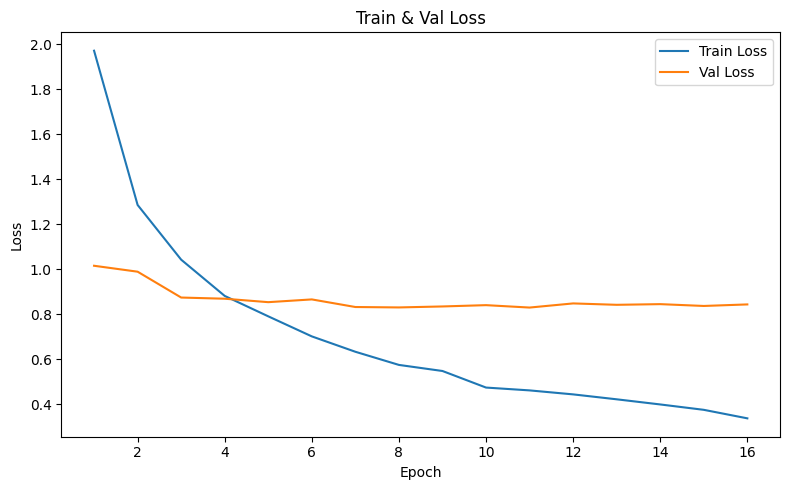

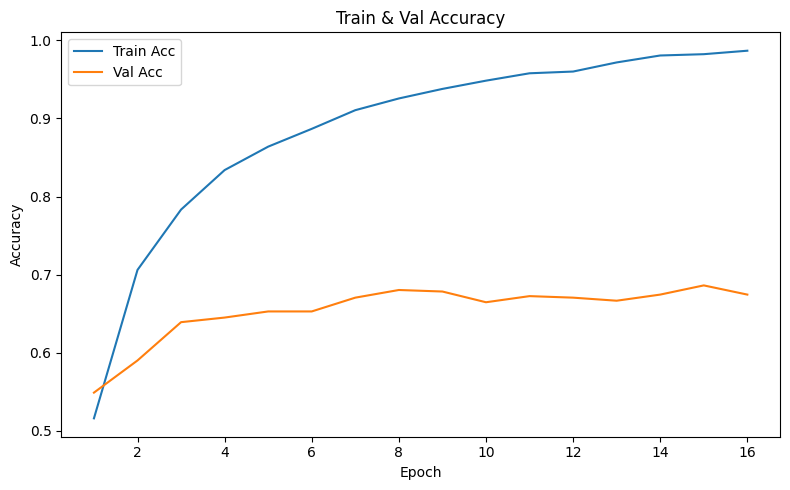

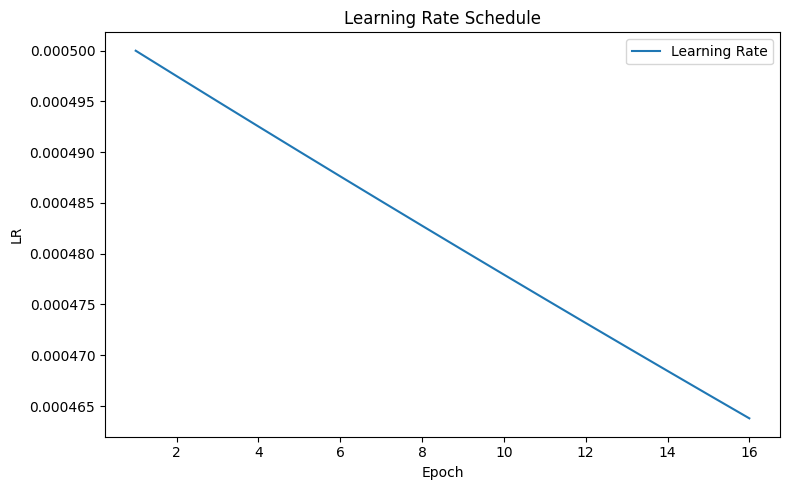

In [37]:
mlp = MLPClassifier(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_layers=[64],
    dropout_rate=0.7,
    learning_rate=5e-4,
    momentum=0.9,
    lr_decay=0.995,
)

history = mlp.fit(
    X_train_std, y_train,
    X_val_std, y_val,
    num_epochs=60,
    batch_size=32,
    early_stopping=True,
    patience=5,
    verbose=True,
)

# 1) Loss versus accuracy curve
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train & Val Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train & Val Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["lrs"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Test Set Evaluation and Confusion Matrix

This section evaluates the accuracy of the final model on the training set, validation set, and test set respectively, and presents the normalized confusion matrix of the test set to analyze the model's performance in various categories.

In [38]:
# 2) Performance of each dataset
print("Use the best hyperparameter evaluation model...")

train_results = mlp.evaluate(X_train_std, y_train)
val_results = mlp.evaluate(X_val_std, y_val)
test_results = mlp.evaluate(X_test_std, y_test)

print(f"Train accuracy: {train_results['accuracy']:.4f}")
print(f"Val   accuracy: {val_results['accuracy']:.4f}")
print(f"Test  accuracy: {test_results['accuracy']:.4f}")

# 3) More detailed (including ROC/PR)
train_eval = evaluate_classifier_np(
    "MLP (train)", mlp.predict, mlp.predict_proba,
    X_train_std, y_train, num_classes
)
val_eval = evaluate_classifier_np(
    "MLP (val)", mlp.predict, mlp.predict_proba,
    X_val_std, y_val, num_classes
)
test_eval = evaluate_classifier_np(
    "MLP (test)", mlp.predict, mlp.predict_proba,
    X_test_std, y_test, num_classes
)

Use the best hyperparameter evaluation model...
Train accuracy: 0.9656
Val   accuracy: 0.6725
Test  accuracy: 0.6314
[MLP (train)] accuracy=0.9656, macro-F1=0.9656
[MLP (train)] per-class ROC-AUC: [np.float64(0.9979437499999972), np.float64(0.9964236111111084), np.float64(0.9969680555555529)]
[MLP (train)] per-class AP:      [0.9532752513268964, 0.9821255974637684, 0.897963906070177]
Confusion matrix:
 [[581  10   9]
 [  6 581  13]
 [  7  17 576]]
[MLP (val)] accuracy=0.6725, macro-F1=0.6730
[MLP (val)] per-class ROC-AUC: [np.float64(0.8443046902550768), np.float64(0.805416318574206), np.float64(0.8615120397230697)]
[MLP (val)] per-class AP:      [0.724044091608979, 0.7115154065005215, 0.6627313921566671]
Confusion matrix:
 [[121  41  19]
 [ 29 111  28]
 [ 26  24 111]]
[MLP (test)] accuracy=0.6314, macro-F1=0.6313
[MLP (test)] per-class ROC-AUC: [np.float64(0.8293823576842367), np.float64(0.7870424521810857), np.float64(0.836739860588357)]
[MLP (test)] per-class AP:      [0.70425200386

C:\Users\Tianqi.Gao25\AppData\Local\Temp\ipykernel_11180\1914232219.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y_sorted, x_sorted)
C:\Users\Tianqi.Gao25\AppData\Local\Temp\ipykernel_11180\1914232219.py:113: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_val = float(np.trapz(precisions, recalls))


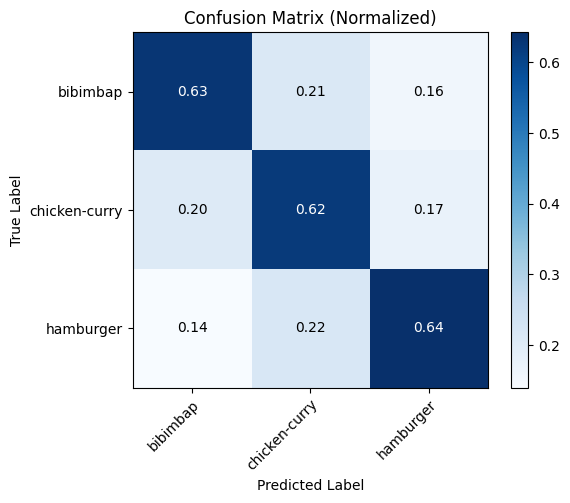

In [39]:
# 4) Test set confusion matrix + normalization
cm = test_eval["confusion_matrix"]
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(num_classes),
    yticks=np.arange(num_classes),
    xticklabels=class_names,
    yticklabels=class_names,
    ylabel="True Label",
    xlabel="Predicted Label",
    title="Confusion Matrix (Normalized)",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black")
plt.tight_layout()
plt.show()

## 7. Summary of ROC/PR Curves and Indicators

To evaluate the model performance more comprehensively, this section plots the multi-class ROC curves and Precision-Recall curves on the test set, and presents the AUC and AP metrics for each class.

C:\Users\Tianqi.Gao25\AppData\Local\Temp\ipykernel_11180\1914232219.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y_sorted, x_sorted)


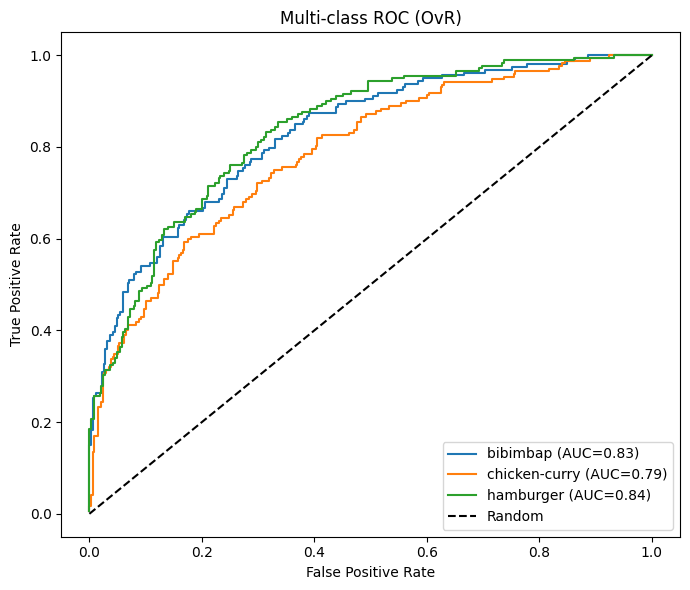

In [40]:
# 5) Multi-class ROC curves (OvR) of the test set
probs_test = mlp.predict_proba(X_test_std)

plt.figure(figsize=(7, 6))
for i, cls in enumerate(class_names):
    y_true_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve_np(y_true_binary, probs_test[:, i])
    roc_auc = auc_np(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC (OvR)")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Tianqi.Gao25\AppData\Local\Temp\ipykernel_11180\1914232219.py:113: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_val = float(np.trapz(precisions, recalls))


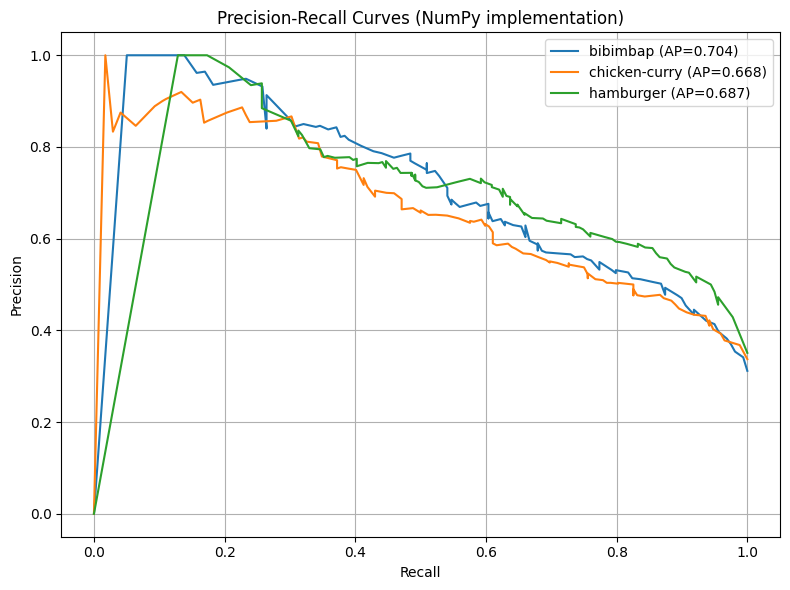

In [41]:
# 6) Test set Multi-class PR Curves (Implemented in NumPy)
thresholds_pr, prec_list, rec_list, ap_list = pr_curve_ovr(y_test, probs_test, num_classes)

plt.figure(figsize=(8, 6))
for c, cls in enumerate(class_names):
    plt.plot(rec_list[c], prec_list[c], label=f"{cls} (AP={ap_list[c]:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (NumPy implementation)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
results_summary = pd.DataFrame({
    "Dataset": ["Train", "Val", "Test"],
    "Accuracy": [
        f"{train_eval['accuracy']:.4f}",
        f"{val_eval['accuracy']:.4f}",
        f"{test_eval['accuracy']:.4f}",
    ],
    "Macro Precision": [
        f"{train_eval['precision_macro']:.4f}",
        f"{val_eval['precision_macro']:.4f}",
        f"{test_eval['precision_macro']:.4f}",
    ],
    "Macro Recall": [
        f"{train_eval['recall_macro']:.4f}",
        f"{val_eval['recall_macro']:.4f}",
        f"{test_eval['recall_macro']:.4f}",
    ],
    "Macro F1": [
        f"{train_eval['f1_macro']:.4f}",
        f"{val_eval['f1_macro']:.4f}",
        f"{test_eval['f1_macro']:.4f}",
    ],
    "Mean ROC-AUC": [
        f"{np.mean(train_eval['roc_auc_list']):.4f}",
        f"{np.mean(val_eval['roc_auc_list']):.4f}",
        f"{np.mean(test_eval['roc_auc_list']):.4f}",
    ],
})

results_summary

,Dataset,Accuracy,Macro Precision,Macro Recall,Macro F1,Mean ROC-AUC
0,Train,0.9656,0.9656,0.9656,0.9656,0.9971
1,Val,0.6725,0.6736,0.6729,0.6730,0.8371
2,Test,0.6314,0.6320,0.6312,0.6313,0.8177
